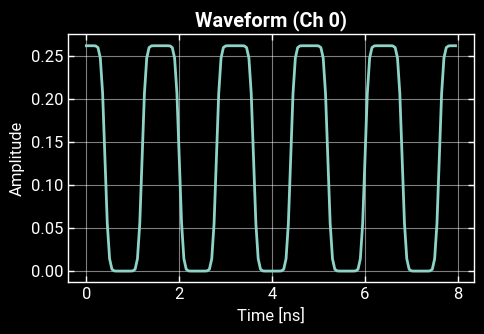

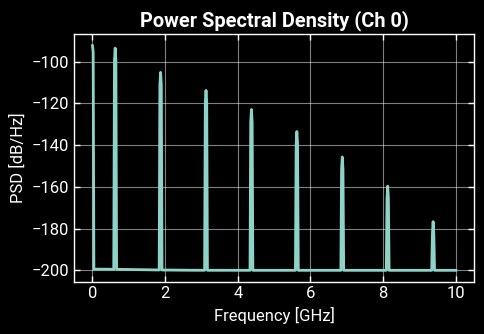

In [12]:
import numpy as np

from commstools import Signal, filtering

sampling_rate = 20e9
symbol_rate = 0.625e9
sps = int(sampling_rate / symbol_rate)

num_samples = 20_000
num_symbols = num_samples // sps

symbols = [1, 1] * (num_symbols // 2)
symbols = np.asarray(symbols, dtype=float)[None, :]

# Apply pulse shaping
# shape_pulse defaults to axis=-1 (Time) which is correct for (C, T)
samples = filtering.shape_pulse(
    symbols=symbols,
    sps=sps,
    pulse_shape="smoothrect",
    # pulse_width=0.1,
    rise_time=0.1,
    rz=True,
)

s = Signal(
    samples=samples,
    sampling_rate=sampling_rate,
    symbol_rate=symbol_rate,
)
s.plot_waveform(show=True, num_symbols=5)
s.plot_psd(show=True, nperseg=1024)


In [28]:
ss = Signal.pam(
    num_symbols=10, sps=sps, symbol_rate=symbol_rate, order=2, rz=True, unipolar=True
)


(<Figure size 500x350 with 1 Axes>,
 <Axes: title={'center': 'Waveform'}, xlabel='Time [ns]', ylabel='Amplitude'>)

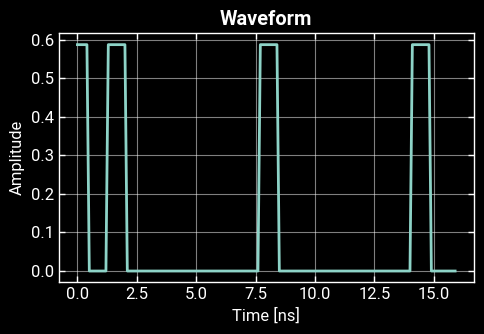

In [29]:
ss.plot_waveform()


In [31]:
ss.source_symbols


array([1.5811388, 1.5811388, 0.       , 0.       , 0.       , 1.5811388,
       0.       , 0.       , 0.       , 1.5811388], dtype=float32)